In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
!pip install torch torchvision grad-cam scikit-learn matplotlib -q

import os
import copy
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 70.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
DATA_DIR = "/content/drive/MyDrive/projects/Fabric_Dataset.zip"   # <-- update this path
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
IMG_SIZE = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
import zipfile
import os

# Define the path to the original zip file from the initial setup
original_zip_file_path = "/content/drive/MyDrive/projects/Fabric_Dataset.zip"

# Define the directory where the dataset will be extracted
extract_path = "/content/drive/MyDrive/Fabric_Dataset" # This will be the new DATA_DIR for ImageFolder

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
if os.path.exists(original_zip_file_path):
    with zipfile.ZipFile(original_zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Dataset extracted to: {extract_path}")
else:
    print(f"Error: Zip file not found at {original_zip_file_path}")

# Check the structure
print("Contents of extract_path:", os.listdir(extract_path))
# Output: ['Dataset']

# ✅ CORRECT: Point to the inner 'Dataset' folder
DATA_DIR = os.path.join(extract_path, 'Dataset')

# Verify the class folders
print(f"DATA_DIR set to: {DATA_DIR}")
print("Class folders:", os.listdir(DATA_DIR))

Dataset extracted to: /content/drive/MyDrive/Fabric_Dataset
Contents of extract_path: ['Dataset']
DATA_DIR set to: /content/drive/MyDrive/Fabric_Dataset/Dataset
Class folders: ['Broken stitch', 'Needle mark', 'Pinched fabric', 'Vertical', 'defect free', 'hole', 'horizontal', 'lines', 'stain']


In [5]:

# ── Data loading & augmentation ──────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")
print(f"Total images: {len(full_dataset)}")

Classes (9): ['Broken stitch', 'Needle mark', 'Pinched fabric', 'Vertical', 'defect free', 'hole', 'horizontal', 'lines', 'stain']
Total images: 3067


In [6]:
# 70/15/15 train/val/test split
n = len(full_dataset)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val
train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)
# Val/test should use eval_transform (no augmentation) -- swap the transform
val_ds.dataset.transform = eval_transform
test_ds.dataset.transform = eval_transform

In [7]:
# ── Handle class imbalance with weighted sampling ────────────────────────
targets = [full_dataset.samples[i][1] for i in train_ds.indices]
class_counts = np.bincount(targets, minlength=num_classes)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = [class_weights[t] for t in targets]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Class distribution in training set: {dict(zip(class_names, class_counts))}")

Class distribution in training set: {'Broken stitch': np.int64(80), 'Needle mark': np.int64(78), 'Pinched fabric': np.int64(73), 'Vertical': np.int64(74), 'defect free': np.int64(1153), 'hole': np.int64(194), 'horizontal': np.int64(99), 'lines': np.int64(113), 'stain': np.int64(282)}


In [8]:
# ── Model: transfer learning on ResNet50 ─────────────────────────────────
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in model.parameters():
    param.requires_grad = False  # freeze backbone initially

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, num_classes)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 112MB/s] 


In [ ]:
# ── Training loop ─────────────────────────────────────────────────────────

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

best_val_acc = 0.0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    # Unfreeze backbone after a few epochs for fine-tuning
    if epoch == 5:
        for param in model.parameters():
            param.requires_grad = True
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE / 10)
        print("Unfroze backbone, continuing fine-tuning at lower LR")

    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_state)
torch.save(model.state_dict(), "/content/drive/MyDrive/projects/fabric_defect_classifier.pt")
print(f"\nBest validation accuracy: {best_val_acc:.4f}")
print("Saved model weights to /content/drive/MyDrive/projects/fabric_defect_classifier.pt")


Epoch 1/15 | train_loss=0.7543 train_acc=0.7992 | val_loss=0.5589 val_acc=0.8652
Epoch 2/15 | train_loss=0.5240 train_acc=0.8579 | val_loss=0.4454 val_acc=0.8913
Epoch 3/15 | train_loss=0.4143 train_acc=0.8910 | val_loss=0.3243 val_acc=0.9174
Epoch 4/15 | train_loss=0.2979 train_acc=0.9287 | val_loss=0.2696 val_acc=0.9109
Epoch 5/15 | train_loss=0.2282 train_acc=0.9432 | val_loss=0.2311 val_acc=0.9239
Unfroze backbone, continuing fine-tuning at lower LR
Epoch 6/15 | train_loss=0.1781 train_acc=0.9576 | val_loss=0.1945 val_acc=0.9413
Epoch 7/15 | train_loss=0.1507 train_acc=0.9609 | val_loss=0.1691 val_acc=0.9413
Epoch 8/15 | train_loss=0.1097 train_acc=0.9776 | val_loss=0.1535 val_acc=0.9500
Epoch 9/15 | train_loss=0.0890 train_acc=0.9776 | val_loss=0.1464 val_acc=0.9522
Epoch 10/15 | train_loss=0.0710 train_acc=0.9804 | val_loss=0.1418 val_acc=0.9522
Epoch 11/15 | train_loss=0.0744 train_acc=0.9832 | val_loss=0.1216 val_acc=0.9543
Epoch 12/15 | train_loss=0.0518 train_acc=0.9907 | val

In [9]:
import os
import torch

model_save_path = "/content/drive/MyDrive/projects/fabric_defect_classifier.pt"

# Load the saved model weights
if os.path.exists(model_save_path):
    print(f"Loading model weights from {model_save_path}.")
    # Make sure 'model' and 'device' are defined in a previous cell
    # If they are not, you might need to run the model definition cell first.
    model.load_state_dict(torch.load(model_save_path, map_location=device))
    model.to(device) # Ensure model is on the correct device
    print("Model loaded successfully. The model object 'model' is now ready for use.")
else:
    print(f"Error: Model weights not found at {model_save_path}. Please run the training cell (jUSC-IR70xiH) to train and save the model first.")

Loading model weights from /content/drive/MyDrive/projects/fabric_defect_classifier.pt.
Model loaded successfully. The model object 'model' is now ready for use.



=== Test Set Performance (report these honest numbers on your CV) ===
                precision    recall  f1-score   support

 Broken stitch      1.000     1.000     1.000        13
   Needle mark      1.000     1.000     1.000        14
Pinched fabric      1.000     1.000     1.000        13
      Vertical      0.867     0.929     0.897        14
   defect free      1.000     0.958     0.978       261
          hole      0.949     0.902     0.925        41
    horizontal      0.960     1.000     0.980        24
         lines      0.920     0.920     0.920        25
         stain      0.836     1.000     0.911        56

      accuracy                          0.961       461
     macro avg      0.948     0.968     0.957       461
  weighted avg      0.965     0.961     0.962       461



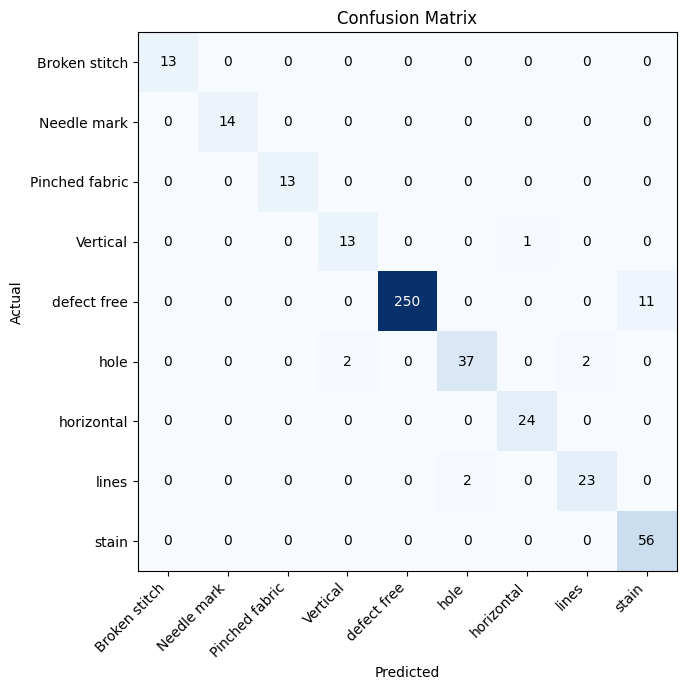

In [10]:
# ── Final evaluation on held-out test set ────────────────────────────────
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device);
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\n=== Test Set Performance (report these honest numbers on your CV) ===")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(num_classes)); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(num_classes)); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion Matrix")
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/projects/confusion_matrix.png", dpi=150)
plt.show()


In [11]:
# ── Grad-CAM: visualize what the model is looking at ────────────────────
# pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

def generate_gradcam(image_path, model, class_names, save_path="gradcam_output.png"):
    target_layer = model.layer4[-1]
    cam = GradCAM(model=model, target_layers=[target_layer])

    img = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img) / 255.0
    input_tensor = eval_transform(img).unsqueeze(0).to(device)

    grayscale_cam = cam(input_tensor=input_tensor)[0]
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = output.argmax(1).item()
        confidence = torch.softmax(output, dim=1)[0, pred_idx].item()

    plt.figure(figsize=(6, 6))
    plt.imshow(visualization)
    plt.title(f"Predicted: {class_names[pred_idx]} ({confidence:.1%})")
    plt.axis("off")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_path}")
    return class_names[pred_idx], confidence

🎲 Randomly selected: /content/drive/MyDrive/Fabric_Dataset/Dataset/defect free/39052557c5e244b91334562121.jpg


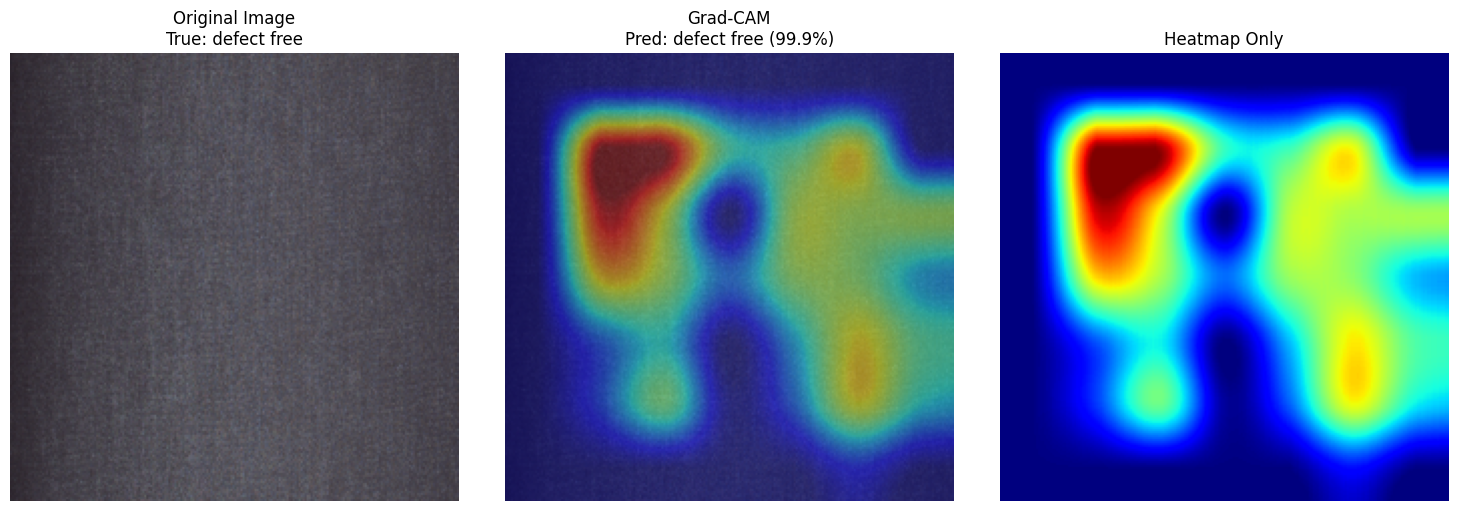

✅ Saved gradcam_random_39052557c5e244b91334562121.png


In [12]:
import glob
import random
import torch.nn.functional as F

# ── Grad-CAM: visualize what the model is looking at ────────────────────
# pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

def generate_gradcam(image_path, model, class_names, save_path="gradcam_output.png"):
    target_layer = model.layer4[-1]
    cam = GradCAM(model=model, target_layers=[target_layer])

    img = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img) / 255.0
    input_tensor = eval_transform(img).unsqueeze(0).to(device)

    grayscale_cam = cam(input_tensor=input_tensor)[0]
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = output.argmax(1).item()
        confidence = torch.softmax(output, dim=1)[0, pred_idx].item()

    plt.figure(figsize=(6, 6))
    plt.imshow(visualization)
    plt.title(f"Predicted: {class_names[pred_idx]} ({confidence:.1%})")
    plt.axis("off")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_path}")
    return class_names[pred_idx], confidence

def show_random_gradcam(model, class_names, dataset_dir):
    """
    Shows Grad-CAM on a single random image from the dataset.
    Each run picks a different random image.
    """
    global gradients, feature_maps

    # Collect all images
    all_images = []
    for class_name in class_names:
        class_folder = os.path.join(dataset_dir, class_name)
        if os.path.exists(class_folder):
            images_in_class = (
                glob.glob(os.path.join(class_folder, "*.jpg"))
                + glob.glob(os.path.join(class_folder, "*.jpeg"))
                + glob.glob(os.path.join(class_folder, "*.png"))
            )
            all_images.extend(images_in_class)

    if not all_images:
        print("No images found!")
        return

    # Pick ONE random image
    image_path = random.choice(all_images)
    print(f"🎲 Randomly selected: {image_path}")

    # Get target layer and register hooks
    target_layer = model.layer4[-1].conv3

    def save_gradient(grad):
        global gradients
        gradients = grad

    def save_feature_map(module, input, output):
        global feature_maps
        feature_maps = output

    forward_handle = target_layer.register_forward_hook(save_feature_map)
    backward_handle = target_layer.register_full_backward_hook(
        lambda module, grad_input, grad_output: save_gradient(grad_output[0])
    )

    # Process the image
    try:
        # Reset
        gradients = None
        feature_maps = None

        # Load and prepare image
        img = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        img_np = np.array(img) / 255.0
        input_tensor = eval_transform(img).unsqueeze(0).to(device)
        input_tensor.requires_grad = True

        # Forward pass
        model.eval()
        model.zero_grad()
        output = model(input_tensor)
        pred_idx = output.argmax(1).item()
        confidence = torch.softmax(output, dim=1)[0, pred_idx].item()

        # Backward pass
        output[0, pred_idx].backward()

        # Generate CAM
        if gradients is not None and feature_maps is not None:
            weights = torch.mean(gradients, dim=[2, 3], keepdim=True)
            cam = torch.sum(weights * feature_maps, dim=1, keepdim=True)
            cam = F.relu(cam)
            cam = cam.squeeze().cpu().detach().numpy()
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
            cam = np.uint8(255 * cam)
            cam = np.array(Image.fromarray(cam).resize((IMG_SIZE, IMG_SIZE)))

            heatmap = plt.cm.jet(cam)[:, :, :3] * 255
            overlay = 0.5 * img_np * 255 + 0.5 * heatmap
            overlay = np.clip(overlay, 0, 255).astype(np.uint8)

            # Get true label
            true_label = os.path.basename(os.path.dirname(image_path))

            # Display
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

            ax1.imshow(img)
            ax1.set_title(f"Original Image\nTrue: {true_label}", fontsize=12)
            ax1.axis('off')

            ax2.imshow(overlay)
            ax2.set_title(f"Grad-CAM\nPred: {class_names[pred_idx]} ({confidence:.1%})", fontsize=12)
            ax2.axis('off')

            # Also show just the heatmap
            ax3.imshow(cam, cmap='jet')
            ax3.set_title("Heatmap Only", fontsize=12)
            ax3.axis('off')

            plt.tight_layout()
            plt.savefig(f"gradcam_random_{image_path.split('/')[-1].split('.')[0]}.png", dpi=150, bbox_inches='tight')
            plt.show()
            print(f"✅ Saved gradcam_random_{image_path.split('/')[-1].split('.')[0]}.png")

        else:
            print("Failed to generate Grad-CAM")

    except Exception as e:
        print(f"Error: {e}")

    # Remove hooks
    forward_handle.remove()
    backward_handle.remove()

# Run it - each time you run this cell, you'll get a different random image
show_random_gradcam(model, class_names, DATA_DIR)

In [13]:
# ── RAG System Imports ──

# Install required packages (run once)
!pip install sentence-transformers google-generativeai -q

import json
import os
import numpy as np
from sentence_transformers import SentenceTransformer
import google.generativeai as genai

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [14]:
import json

# ── Load Knowledge Base ──

# Save your knowledge base JSON to a file
knowledge_base_data = [
  {
    "id": "kb001",
    "defect_type": "hole",
    "category": "definition",
    "content": "A hole is a break or puncture in the fabric structure where yarns are missing or torn, creating a visible gap. Common causes include mechanical damage during weaving/knitting, pest damage, or handling damage in the cutting room."
  },
  {
    "id": "kb002",
    "defect_type": "hole",
    "category": "severity",
    "content": "Holes are classified as a critical/major defect under standard 4-point fabric inspection systems, since they directly compromise garment structural integrity and cannot be corrected. Even a single hole in a garment panel typically results in rejection of that panel."
  },
  {
    "id": "kb003",
    "defect_type": "hole",
    "category": "action",
    "content": "Recommended action for a detected hole: reject the affected fabric section entirely, do not attempt rework. Flag the roll/batch for supplier feedback if hole frequency exceeds normal tolerance, and re-inspect surrounding fabric area for additional damage."
  },
  {
    "id": "kb004",
    "defect_type": "stain",
    "category": "definition",
    "content": "A stain is a discoloration or contamination mark on the fabric surface, caused by oil, dirt, dye bleeding, rust from machinery, or chemical spotting during processing or storage."
  },
  {
    "id": "kb005",
    "defect_type": "stain",
    "category": "severity",
    "content": "Stain severity depends on size and visibility. Small stains (under 3mm) in non-visible garment areas may fall within buyer tolerance under a points system. Large or dark stains, or any stain in a highly visible panel (front body, collar), are typically treated as major defects."
  },
  {
    "id": "kb006",
    "defect_type": "stain",
    "category": "action",
    "content": "Recommended action for a detected stain: attempt spot-cleaning only if the stain type is known and treatable (e.g. water-based marks); if untreatable or in a visible panel, reject the section. Always verify against buyer-specific AQL tolerance before batch-level rejection, since some buyers accept minor stains in non-visible areas."
  },
  {
    "id": "kb007",
    "defect_type": "broken stitch",
    "category": "definition",
    "content": "A broken stitch defect refers to discontinuous or snapped stitching along a seam, causing the seam to weaken or open. This typically occurs due to needle damage, incorrect tension settings, or thread quality issues during sewing."
  },
  {
    "id": "kb008",
    "defect_type": "broken stitch",
    "category": "severity",
    "content": "Broken stitches are a major defect, particularly in load-bearing seams (side seams, shoulder seams, crotch seams) where seam failure during wear is a real risk. Broken stitches in decorative or non-structural stitching are lower severity."
  },
  {
    "id": "kb009",
    "defect_type": "broken stitch",
    "category": "action",
    "content": "Recommended action for broken stitch: route to rework for re-stitching rather than outright rejection, since this defect is correctable. Verify thread tension settings on the machine used to prevent recurrence in the same batch."
  },
  {
    "id": "kb010",
    "defect_type": "needle mark",
    "category": "definition",
    "content": "A needle mark is a small hole or puncture pattern left in the fabric by sewing needles, often visible as a line of tiny perforations where a seam was unpicked or a garment was re-sewn."
  },
  {
    "id": "kb011",
    "defect_type": "needle mark",
    "category": "severity",
    "content": "Needle marks are typically a minor-to-moderate defect. Isolated needle marks from normal construction are often within tolerance, but visible needle marks from unpicking/rework on visible panels are flagged as moderate defects since they affect garment appearance."
  },
  {
    "id": "kb012",
    "defect_type": "needle mark",
    "category": "action",
    "content": "Recommended action for needle marks: assess visibility under standard inspection lighting and distance (typically 1 meter). If marks are visible at standard inspection distance on a main panel, flag for review; otherwise accept within tolerance."
  },
  {
    "id": "kb013",
    "defect_type": "pinched fabric",
    "category": "definition",
    "content": "Pinched fabric refers to a fold, pucker, or tuck accidentally caught in a seam during sewing, creating an unintended crease or bunching in the fabric that was not part of the garment design."
  },
  {
    "id": "kb014",
    "defect_type": "pinched fabric",
    "category": "severity",
    "content": "Pinched fabric is typically a moderate defect affecting appearance and fit rather than structural integrity. Severity increases if the pinch is on a highly visible panel or affects garment drape significantly."
  },
  {
    "id": "kb015",
    "defect_type": "pinched fabric",
    "category": "action",
    "content": "Recommended action for pinched fabric: route to rework for unpicking and re-sewing the affected seam section. This is generally correctable without fabric replacement."
  },
  {
    "id": "kb016",
    "defect_type": "horizontal",
    "category": "definition",
    "content": "Horizontal line/bar defects appear as unwanted horizontal streaks or bands running across the fabric width, commonly caused by weft-related issues in weaving (weft bars), inconsistent yarn tension, or dyeing irregularities."
  },
  {
    "id": "kb017",
    "defect_type": "horizontal",
    "category": "severity",
    "content": "Horizontal bar defects are moderate-to-major depending on contrast and visibility. Faint bars visible only under close inspection may be within tolerance; strongly contrasted bars visible at normal viewing distance are major defects and often indicate a systemic issue with an entire fabric roll rather than an isolated flaw."
  },
  {
    "id": "kb018",
    "defect_type": "horizontal",
    "category": "action",
    "content": "Recommended action for horizontal bar defects: if isolated to a small section, cut around the defect during pattern cutting. If the defect recurs across the roll, reject the entire roll and flag for supplier-level investigation into weaving/dyeing process."
  },
  {
    "id": "kb019",
    "defect_type": "vertical",
    "category": "definition",
    "content": "Vertical line defects appear as streaks running along the fabric length (warp direction), typically caused by broken or uneven warp yarns, tension irregularities during weaving, or knitting needle malfunctions."
  },
  {
    "id": "kb020",
    "defect_type": "vertical",
    "category": "severity",
    "content": "Vertical line defects are treated similarly to horizontal bars in severity assessment: moderate if faint and isolated, major if strongly visible or recurring, since they often indicate an ongoing mechanical fault in the loom or knitting machine rather than a one-off flaw."
  },
  {
    "id": "kb021",
    "defect_type": "vertical",
    "category": "action",
    "content": "Recommended action for vertical line defects: inspect adjacent fabric sections for recurrence, since a mechanical cause typically produces the defect repeatedly along the roll length. Reject affected sections; escalate to supplier if the pattern repeats consistently."
  },
  {
    "id": "kb022",
    "defect_type": "lines",
    "category": "definition",
    "content": "General line defects (not clearly horizontal or vertical) cover irregular streaking, slub lines, or thickness variation lines in the fabric surface, often from uneven yarn thickness or spinning defects."
  },
  {
    "id": "kb023",
    "defect_type": "lines",
    "category": "severity",
    "content": "Line defects are generally moderate severity, assessed primarily on visibility and whether they affect fabric hand-feel or only appearance. Note this defect type can visually resemble hole or stain defects in classifier predictions, so a confidence check and manual double-check is advised for low-confidence predictions."
  },
  {
    "id": "kb024",
    "defect_type": "lines",
    "category": "action",
    "content": "Recommended action for line defects: assess under standard lighting at normal inspection distance. If within buyer's accepted points-per-100-yards tolerance, accept with note; otherwise reject the affected section."
  },
  {
    "id": "kb025",
    "defect_type": "defect free",
    "category": "definition",
    "content": "Defect-free fabric shows no visible structural, surface, or color irregularities under standard inspection conditions and passes all quality checkpoints for the intended garment use."
  },
  {
    "id": "kb026",
    "defect_type": "defect free",
    "category": "action",
    "content": "Defect-free fabric proceeds directly to the next production stage (cutting/sewing) without rework. Note: this classifier has a known tendency to occasionally flag clean fabric as a minor stain (false positive); when confidence is below 85% on a defect-free vs stain distinction, route to quick manual visual check rather than auto-rejecting."
  },
  {
    "id": "kb027",
    "defect_type": "general",
    "category": "aql_standard",
    "content": "Most garment QC programs use Acceptable Quality Limit (AQL) sampling and 4-point fabric inspection systems, where defects are scored by size (points 1-4) and total points per 100 square yards determine roll acceptance. This is industry-standard practice referenced generally in textile QC, and specific buyer thresholds vary by contract."
  },
  {
    "id": "kb028",
    "defect_type": "general",
    "category": "confidence_handling",
    "content": "For any AI-assisted defect classification, predictions below 85% confidence should be routed to human review rather than auto-actioned, regardless of predicted defect type. This is standard practice for human-in-the-loop QC systems to avoid compounding classifier errors into shipping decisions."
  },
  {
    "id": "kb029",
    "defect_type": "general",
    "category": "escalation",
    "content": "Any defect type occurring at a rate significantly above historical baseline for a given fabric roll or supplier batch should be escalated beyond individual-piece rejection to a batch-level quality review, since recurring defects often indicate a process or machine fault rather than isolated flaws."
  }
]

# Save to file
with open("qc_knowledge_base.json", "w") as f:
    json.dump(knowledge_base_data, f, indent=2)

print(f"✅ Knowledge base saved: {len(knowledge_base_data)} entries")

✅ Knowledge base saved: 29 entries


In [15]:
# ── Build the searchable knowledge base (embeddings) ──────────────────────
# This turns each of your 29 knowledge base entries into a vector (a list of
# numbers) so we can find the most relevant ones for any defect type later.

embedder = SentenceTransformer("all-MiniLM-L6-v2")  # free, runs locally, no API key needed

# Turn every entry's "content" text into an embedding
kb_texts = [entry["content"] for entry in knowledge_base_data]
kb_embeddings = embedder.encode(kb_texts, normalize_embeddings=True)

print(f"Embedded {len(kb_texts)} knowledge base entries")
print(f"Each entry is now a vector of {kb_embeddings.shape[1]} numbers")


def search_knowledge_base(query, top_k=3, defect_type_filter=None):
    """
    Given a question (query), find the top_k most relevant knowledge base
    entries. If defect_type_filter is set, only search within that defect
    type's entries (plus 'general' entries).
    """
    query_vec = embedder.encode([query], normalize_embeddings=True)[0]

    # Cosine similarity: since both vectors are normalized, a simple dot
    # product tells us how "close" the query is to each entry (1.0 = identical
    # meaning, 0 = unrelated, -1 = opposite)
    similarities = kb_embeddings @ query_vec

    candidates = list(enumerate(similarities))
    if defect_type_filter:
        candidates = [
            (i, score) for i, score in candidates
            if knowledge_base_data[i]["defect_type"] in (defect_type_filter, "general")
        ]

    candidates.sort(key=lambda x: x[1], reverse=True)
    top_matches = candidates[:top_k]

    return [knowledge_base_data[i] for i, score in top_matches]


# Quick test -- try searching for something and see what comes back
test_results = search_knowledge_base("what should I do if I find a hole?", top_k=3, defect_type_filter="hole")
for r in test_results:
    print(f"[{r['id']}] ({r['category']}): {r['content'][:80]}...")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedded 29 knowledge base entries
Each entry is now a vector of 384 numbers
[kb001] (definition): A hole is a break or puncture in the fabric structure where yarns are missing or...
[kb003] (action): Recommended action for a detected hole: reject the affected fabric section entir...
[kb002] (severity): Holes are classified as a critical/major defect under standard 4-point fabric in...


In [24]:
# ── Set up Gemini ──────────────────────────────────────────────────────────
import getpass

GEMINI_API_KEY = getpass.getpass("Paste your Gemini API key: ")  # hidden input, not saved in notebook
genai.configure(api_key=GEMINI_API_KEY)

gemini_model = genai.GenerativeModel("gemini-2.5-flash-lite")


# ── Query decomposition ─────────────────────────────────────────────────────
# Instead of one search, we ask two separate questions and retrieve for each.
# This is the "advanced RAG technique" -- it means we don't rely on a single
# search to cover both "what is this defect" AND "what do I do about it".
def decompose_query(defect_type, confidence):
    sub_queries = [
        f"What does the {defect_type} defect mean and what causes it?",
        f"What is the severity and recommended action for {defect_type}?",
    ]
    if confidence < 0.85:
        sub_queries.append("How should low-confidence predictions be handled?")
    return sub_queries


def retrieve_context(defect_type, confidence):
    sub_queries = decompose_query(defect_type, confidence)
    retrieved, seen_ids = [], set()
    for q in sub_queries:
        for entry in search_knowledge_base(q, top_k=2, defect_type_filter=defect_type):
            if entry["id"] not in seen_ids:
                retrieved.append(entry)
                seen_ids.add(entry["id"])
    return retrieved


# ── Generation: turn retrieved notes into a QC recommendation ─────────────
def generate_qc_note(defect_type, confidence):
    retrieved = retrieve_context(defect_type, confidence)
    context_text = "\n".join(f"- {e['content']}" for e in retrieved)
    low_conf = confidence < 0.85

    prompt = f"""You are a garment quality-control assistant. A computer vision model
classified a fabric image as follows:

Predicted defect: {defect_type}
Model confidence: {confidence:.1%}
{"NOTE: confidence is below 85% -- flag for human review." if low_conf else ""}

Relevant QC knowledge:
{context_text}

Write a short, plain-language QC note (3-4 sentences) covering: what the defect
is, its severity, the recommended action, and (if confidence is below 85%) an
explicit recommendation to get human verification. No markdown formatting."""

    response = gemini_model.generate_content(prompt)
    return response.text.strip(), [e["id"] for e in retrieved]


# ── Test it with a few example predictions ─────────────────────────────────
test_cases = [("hole", 0.975), ("stain", 0.79), ("broken stitch", 0.91)]

for defect_type, confidence in test_cases:
    note, sources = generate_qc_note(defect_type, confidence)
    print(f"\n{'='*60}")
    print(f"Defect: {defect_type} ({confidence:.1%})")
    print(f"Sources used: {sources}")
    print(f"QC note: {note}")

Paste your Gemini API key: ··········

Defect: hole (97.5%)
Sources used: ['kb001', 'kb002', 'kb003']
QC note: A hole was detected, which is a break in the fabric structure. This is a critical defect that requires immediate rejection of the affected fabric section. No rework should be attempted, and the roll should be flagged if this defect occurs frequently.

Defect: stain (79.0%)
Sources used: ['kb004', 'kb005', 'kb006', 'kb028', 'kb029']
QC note: The AI detected a potential stain on the fabric with 79% confidence, which is below our 85% threshold and requires human verification. Based on the AI's prediction, we should inspect the fabric for discoloration or contamination. If a stain is present and appears significant or in a visible area, it may warrant rejection or further investigation according to buyer specifications; however, please confirm this classification visually before any action is taken.

Defect: broken stitch (91.0%)
Sources used: ['kb007', 'kb008']
QC note: The model

In [25]:
!cp "/content/drive/MyDrive/projects/fabric_defect_classifier.pt" "fabric_defect_classifier.pt"

In [26]:
%%writefile rag_reasoning_layer.py
import os, json
import numpy as np
from sentence_transformers import SentenceTransformer
import google.generativeai as genai

KB_PATH = "qc_knowledge_base.json"
EMBEDDING_MODEL = "all-MiniLM-L6-v2"
GEMINI_MODEL = "gemini-2.5-flash"
CONFIDENCE_THRESHOLD = 0.85

GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")
genai.configure(api_key=GEMINI_API_KEY)

class QCKnowledgeBase:
    def __init__(self, kb_path):
        with open(kb_path, "r") as f:
            self.entries = json.load(f)
        self.embedder = SentenceTransformer(EMBEDDING_MODEL)
        texts = [e["content"] for e in self.entries]
        self.embeddings = self.embedder.encode(texts, normalize_embeddings=True)

    def search(self, query, top_k=3, defect_type_filter=None):
        query_vec = self.embedder.encode([query], normalize_embeddings=True)[0]
        sims = self.embeddings @ query_vec
        candidates = list(enumerate(sims))
        if defect_type_filter:
            candidates = [(i, s) for i, s in candidates
                          if self.entries[i]["defect_type"] in (defect_type_filter, "general")]
        candidates.sort(key=lambda x: x[1], reverse=True)
        return [self.entries[i] for i, _ in candidates[:top_k]]

def decompose_query(defect_type, confidence):
    return [q for q in [
        f"What does the {defect_type} defect mean and what causes it?",
        f"What is the severity and recommended action for {defect_type}?",
        "How should low-confidence predictions be handled?" if confidence < CONFIDENCE_THRESHOLD else None,
    ] if q]

def retrieve_context(kb, defect_type, confidence):
    retrieved, seen = [], set()
    for q in decompose_query(defect_type, confidence):
        for r in kb.search(q, top_k=2, defect_type_filter=defect_type):
            if r["id"] not in seen:
                retrieved.append(r); seen.add(r["id"])
    return retrieved

def generate_qc_note(defect_type, confidence, retrieved_context):
    context_text = "\n".join(f"- {e['content']}" for e in retrieved_context)
    low_conf = confidence < CONFIDENCE_THRESHOLD
    prompt = f"""You are a garment quality-control assistant. Predicted defect: {defect_type}
Model confidence: {confidence:.1%}
{"NOTE: confidence below 85% -- flag for human review." if low_conf else ""}
Relevant QC knowledge:
{context_text}
Write a short, plain-language QC note (3-4 sentences): what the defect is, severity,
recommended action, and if confidence is below 85%, explicitly recommend human verification.
No markdown."""
    model = genai.GenerativeModel(GEMINI_MODEL)
    return model.generate_content(prompt).text.strip()

def get_qc_note(defect_type, confidence, kb):
    if defect_type == "defect free" and confidence >= CONFIDENCE_THRESHOLD:
        return {"note": "Fabric passed inspection with no defects detected. Proceed to next production stage.",
                "needs_human_review": False}
    retrieved = retrieve_context(kb, defect_type, confidence)
    note = generate_qc_note(defect_type, confidence, retrieved)
    return {"note": note, "needs_human_review": confidence < CONFIDENCE_THRESHOLD}

Writing rag_reasoning_layer.py


In [27]:
%%writefile streamlit_app.py
import os, numpy as np, streamlit as st, torch, torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from rag_reasoning_layer import QCKnowledgeBase, get_qc_note, KB_PATH

MODEL_PATH = "fabric_defect_classifier.pt"
IMG_SIZE = 224
CLASS_NAMES = ["Broken stitch", "Needle mark", "Pinched fabric", "Vertical",
               "defect free", "hole", "horizontal", "lines", "stain"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])

@st.cache_resource
def load_model():
    model = models.resnet50(weights=None)
    model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(model.fc.in_features, len(CLASS_NAMES)))
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device); model.eval()
    return model

@st.cache_resource
def load_kb():
    return QCKnowledgeBase(KB_PATH)

st.set_page_config(page_title="Fabric QC Assistant", layout="wide")
st.title("AI Fabric Quality Assurance Assistant")
model = load_model()
kb = load_kb()

uploaded_file = st.file_uploader("Upload a fabric image", type=["jpg","jpeg","png"])
if uploaded_file:
    image = Image.open(uploaded_file).convert("RGB")
    img_resized = image.resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img_resized) / 255.0
    input_tensor = eval_transform(img_resized).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = probs.argmax().item()
        confidence = probs[pred_idx].item()
        predicted_class = CLASS_NAMES[pred_idx]

    cam = GradCAM(model=model, target_layers=[model.layer4[-1]])
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    result = get_qc_note(predicted_class.lower(), confidence, kb)

    col1, col2 = st.columns(2)
    col1.image(image, caption="Original", use_container_width=True)
    col2.image(overlay, caption="Grad-CAM", use_container_width=True)

    if result["needs_human_review"]:
        st.warning(f"**{predicted_class}** ({confidence:.1%}) -- needs human review")
    else:
        st.success(f"**{predicted_class}** ({confidence:.1%})")
    st.write(result["note"])

Writing streamlit_app.py


In [28]:
!pip install streamlit pyngrok grad-cam -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 47.3 MB/s eta 0:00:00


In [29]:
from pyngrok import ngrok
import os

os.environ["GEMINI_API_KEY"] = "******"
ngrok.set_auth_token("******")

get_ipython().system_raw("streamlit run streamlit_app.py &")
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://composite-irritable-juicy.ngrok-free.dev" -> "http://localhost:8501"
